# Forecasting 7 Cluster: LSTM Volatility Forecasting

This notebook trains an LSTM to forecast 21-day forward volatility and compares it against a rolling-volatility baseline, including cluster-level diagnostics.

## 1) Load Data and Cluster Labels

Load the SP500 panel, attach cluster labels, and create a high-risk cluster flag used as a model feature.


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

In [130]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

In [131]:
cluster_map = pd.read_csv("data/sp500_stock_cluster_map.csv")
df = df.merge(cluster_map[["Symbol", "cluster", "Cluster_name"]], on="Symbol", how="left")

df["is_high_risk_cluster"] = (df["cluster"] == 1).astype(int)


## 2) Time Splits and Universe Filtering

Define train/validation/unseen windows and keep only symbols available in all periods for a fair forward test.


In [132]:
# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

In [133]:
# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())

Common stocks: 499


In [134]:
# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train stocks:", train_df["Symbol"].nunique())
print("Val stocks:", val_df["Symbol"].nunique())
print("Unseen stocks:", unseen_df["Symbol"].nunique())

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

Train stocks: 499
Val stocks: 499
Unseen stocks: 499
Train shape: (374800, 12)
Val shape: (124750, 12)
Unseen shape: (125248, 12)


In [135]:
# export and remove unseen
unseen_df.to_csv("data/unseen_holdout_raw.csv", index=False)

# combine train + val for modeling (will split later)
df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Model dataframe shape:", df.shape)
print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

df_raw_dev = df.copy()

Model dataframe shape: (499550, 12)
Train + Val Date range: 2021-03-22 00:00:00 to 2025-03-20 00:00:00


## 3) Feature Engineering

Create return/volatility/range/volume features and the 21-day forward volatility target.


In [136]:
# feature engineering function

import numpy as np

def engineer_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    g = panel_df.groupby("Symbol")

    # simple 1 day return
    panel_df["ret_1"] = g["Close"].pct_change()

    # target: std of stock's daily returns from t+1 to t+21
    panel_df["target_vol_21d"] = (
        g["ret_1"].transform(lambda s: s.shift(-1).rolling(21).std().shift(-20))
    )

    # today's absolute return
    panel_df["ret_abs_1"] = panel_df["ret_1"].abs()

    # std of returns over past 5, 10, 21 days
    for w in [5, 10, 21]:
        panel_df[f"ret_std_{w}"] = g["ret_1"].transform(lambda s: s.rolling(w).std())

    # daily intraday range
    panel_df["hl_range"] = (panel_df["High"] - panel_df["Low"]) / panel_df["Close"]

    for w in [5, 21]:
        panel_df[f"hl_range_mean_{w}"] = g["hl_range"].transform(lambda s: s.rolling(w).mean())

    # relative volume
    for w in [5, 21]:
        panel_df[f"vol_mean_{w}"] = g["Volume"].transform(lambda s: s.rolling(w).mean())
        panel_df[f"vol_rel_{w}"] = panel_df["Volume"] / panel_df[f"vol_mean_{w}"]

    return panel_df


In [137]:
# apply feature engineering to dev set
df = engineer_features(df)

feature_cols = [
    "ret_abs_1",
    "ret_std_5",
    "ret_std_10",
    "ret_std_21",
    "hl_range_mean_5",
    "hl_range_mean_21",
    "vol_rel_5",
    "vol_rel_21",
    "is_high_risk_cluster"
]

target_col = "target_vol_21d"


## 4) Sequence Dataset Construction

Create train/validation panels where each row has full lookback history and a fully contained forward target window.


In [138]:
# Build modeling rows where both sequence history and forward target window are valid.

LOOKBACK = 21
HORIZON = 21

# Keep only finite rows once before split filtering.
df_feat = df.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(df_feat[feature_cols + [target_col]]).all(axis=1)
df_feat = df_feat.loc[finite_mask].copy()

# Endpoint date t must be in split, and target window (t+1 ... t+21) must stay in same split.
df_feat = df_feat.sort_values(["Symbol", "Date"]).copy()
g = df_feat.groupby("Symbol")

# Per-symbol forward availability guard.
df_feat["date_plus_horizon"] = g["Date"].shift(-HORIZON)

train_feat = df_feat[
    (df_feat["Date"] >= TRAIN_START) &
    (df_feat["Date"] <= TRAIN_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= TRAIN_END)
].copy()

val_feat = df_feat[
    (df_feat["Date"] >= VAL_START) &
    (df_feat["Date"] <= VAL_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= VAL_END)
].copy()

print("train_feat:", train_feat.shape)
print("val_feat:", val_feat.shape)


train_feat: (353821, 26)
val_feat: (103781, 26)


In [139]:
def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    panel_df = panel_df.sort_values(["Symbol", "Date"]).copy()

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].to_numpy(dtype=np.float32)
        y_values = g[target_col].to_numpy(dtype=np.float32)
        dates = g["Date"].to_numpy()

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]
            end_date = dates[t]

            if not np.isfinite(X_window).all():
                continue
            if not np.isfinite(y_target):
                continue

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": end_date
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

In [140]:
# Train sequences
X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_train["Date"] = pd.to_datetime(meta_train["Date"])

print("Train:", X_train.shape, y_train.shape)

# Validation needs trailing train context so earliest validation windows are complete.
train_context = (
    train_feat
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

val_with_context = (
    pd.concat([train_context, val_feat], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

X_val_all, y_val_all, meta_val_all = make_sequences(
    val_with_context,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_val_all["Date"] = pd.to_datetime(meta_val_all["Date"])

val_keep = (
    (meta_val_all["Date"] >= VAL_START) &
    (meta_val_all["Date"] <= VAL_END)
)

X_val = X_val_all[val_keep.values]
y_val = y_val_all[val_keep.values]
meta_val = meta_val_all.loc[val_keep].reset_index(drop=True)

print("Val:", X_val.shape, y_val.shape)


Train: (343841, 21, 9) (343841,)
Val: (103781, 21, 9) (103781,)


In [141]:
# scale features and target using train only

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

## 5) LSTM Training and Validation

Train the sequence model, evaluate validation performance, and compare to a simple baseline.


In [142]:
# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - loss: 0.4309 - mae: 0.4491 - val_loss: 0.5804 - val_mae: 0.4929
Epoch 2/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 0.4084 - mae: 0.4389 - val_loss: 0.5805 - val_mae: 0.4880
Epoch 3/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - loss: 0.3997 - mae: 0.4342 - val_loss: 0.5883 - val_mae: 0.4900
Epoch 4/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.3920 - mae: 0.4306 - val_loss: 0.5861 - val_mae: 0.4881
Epoch 5/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.3831 - mae: 0.4270 - val_loss: 0.5878 - val_mae: 0.4901
Epoch 6/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - loss: 0.3740 - mae: 0.4237 - val_loss: 0.5915 - val_mae: 0.4913


In [144]:
val_pred_scaled = model.predict(X_val_scaled).reshape(-1)
val_pred = val_pred_scaled * y_std + y_mean

val_results = meta_val.copy()
val_results["y_true"] = y_val
val_results["y_pred"] = val_pred

# val_results.head()

3244/3244 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [145]:
# Validation metrics for the LSTM.

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(val_results["y_true"], val_results["y_pred"]))
mae = mean_absolute_error(val_results["y_true"], val_results["y_pred"])
r2 = r2_score(val_results["y_true"], val_results["y_pred"])
corr = val_results["y_true"].corr(val_results["y_pred"])

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R2: {r2:.4f}")
print(f"Validation correlation: {corr:.4f}")  # directional tracking

Validation RMSE: 0.0072
Validation MAE: 0.0047
Validation R2: 0.3653
Validation correlation: 0.6050


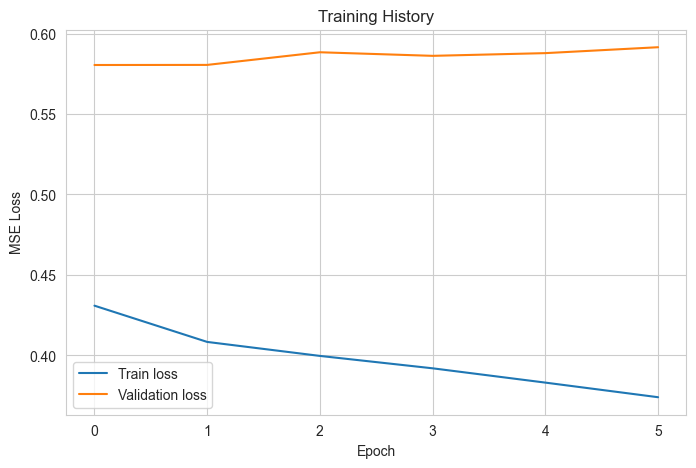

In [146]:
# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## 6) Unseen Holdout Evaluation

Score the model on a strictly forward unseen window and compare with baseline behavior.


In [147]:
# Build unseen panel with trailing dev context, then engineer features on the combined raw panel.

unseen_df = pd.read_csv("data/unseen_holdout_raw.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(unseen_df["Date"].min(), unseen_df["Date"].max())
print(unseen_df.shape)
print("Stocks:", unseen_df["Symbol"].nunique())

dev_context_raw = (
    df_raw_dev
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

unseen_raw_with_context = (
    pd.concat([dev_context_raw, unseen_df], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

unseen_feat_all = engineer_features(unseen_raw_with_context)

unseen_feat = unseen_feat_all[
    (unseen_feat_all["Date"] >= UNSEEN_START) &
    (unseen_feat_all["Date"] <= UNSEEN_END)
].copy()

unseen_feat = unseen_feat.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(unseen_feat[feature_cols + [target_col]]).all(axis=1)
unseen_feat = unseen_feat.loc[finite_mask].copy()

print("unseen_feat:", unseen_feat.shape)


2025-03-21 00:00:00 2026-03-20 00:00:00
(125248, 12)
Stocks: 499
unseen_feat: (114270, 25)


In [148]:
# unseen sequences from engineered panel that already includes raw dev context
X_unseen_all, y_unseen_all, meta_unseen_all = make_sequences(
    unseen_feat_all,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_unseen_all["Date"] = pd.to_datetime(meta_unseen_all["Date"])

unseen_keep = (
    (meta_unseen_all["Date"] >= UNSEEN_START) &
    (meta_unseen_all["Date"] <= UNSEEN_END)
)

X_unseen = X_unseen_all[unseen_keep.values]
y_unseen = y_unseen_all[unseen_keep.values]
meta_unseen = meta_unseen_all.loc[unseen_keep].reset_index(drop=True)

print("Unseen:", X_unseen.shape, y_unseen.shape)

Unseen: (104290, 21, 9) (104290,)


In [149]:
# Unseen evaluation: LSTM vs Baseline (past 21d volatility)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Scale unseen features using train stats only
X_unseen_scaled = (X_unseen - feature_means) / feature_stds

# Predict with LSTM and invert target scaling
unseen_pred_scaled = model.predict(X_unseen_scaled).reshape(-1)
unseen_pred = unseen_pred_scaled * y_std + y_mean

# Build unseen results table (model side)
unseen_results = meta_unseen.copy()
unseen_results["y_true"] = y_unseen
unseen_results["y_pred"] = unseen_pred

# Add baseline prediction (naive = ret_std_21)
baseline_map_unseen = (
    unseen_feat[["Symbol", "Date", "ret_std_21"]]
    .drop_duplicates(["Symbol", "Date"])
    .copy()
)

unseen_eval = unseen_results.merge(
    baseline_map_unseen,
    on=["Symbol", "Date"],
    how="left"
)
unseen_eval["baseline_pred"] = unseen_eval["ret_std_21"]

# Evaluate on same rows for fair comparison
eval_df = unseen_eval.dropna(subset=["y_true", "y_pred", "baseline_pred"]).copy()

def metric_row(y_true, y_hat):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "MAE": mean_absolute_error(y_true, y_hat),
        "R2": r2_score(y_true, y_hat),
        "Correlation": pd.Series(y_true).corr(pd.Series(y_hat)),
    }

comparison = pd.DataFrame(
    {
        "LSTM": metric_row(eval_df["y_true"], eval_df["y_pred"]),
        "Baseline": metric_row(eval_df["y_true"], eval_df["baseline_pred"]),
    }
).T.round(4)

# Print outputs
print(f"Rows evaluated: {len(eval_df)} out of {len(unseen_eval)}")
print("\nUnseen comparison (LSTM vs Baseline):")
print(comparison)

# Preview joined results
print("\nPreview unseen_eval:")
print(unseen_eval[["Symbol", "Date", "y_true", "y_pred", "baseline_pred"]].head(10))


3260/3260 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Rows evaluated: 104290 out of 104290

Unseen comparison (LSTM vs Baseline):
            RMSE     MAE      R2  Correlation
LSTM      0.0075  0.0051  0.3380       0.5842
Baseline  0.0104  0.0069 -0.2746       0.4195

Preview unseen_eval:
  Symbol       Date    y_true    y_pred  baseline_pred
0      A 2025-04-22  0.024946  0.021097       0.033387
1      A 2025-04-23  0.024616  0.021629       0.033762
2      A 2025-04-24  0.024451  0.022359       0.034191
3      A 2025-04-25  0.024932  0.022011       0.034194
4      A 2025-04-28  0.024954  0.023468       0.034265
5      A 2025-04-29  0.025312  0.023654       0.034157
6      A 2025-04-30  0.025517  0.024152       0.034148
7      A 2025-05-01  0.025454  0.025072       0.033898
8      A 2025-05-02  0.025300  0.025004       0.034004
9      A 2025-05-05  0.025551  0.025448       0.031859


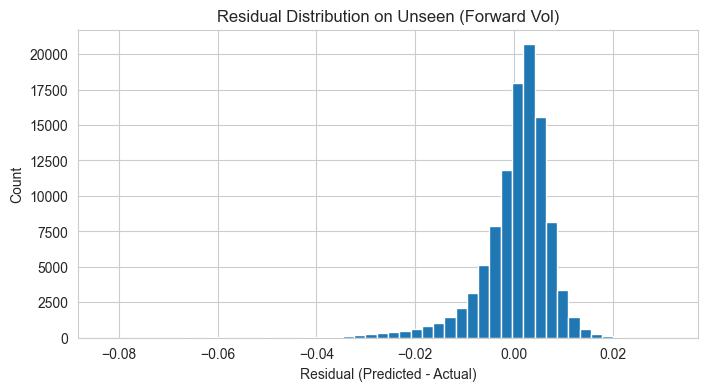

In [150]:
# Generate the unseen residual histogram (LSTM)

import matplotlib.pyplot as plt

# Predict on unseen
X_unseen_scaled = (X_unseen - feature_means) / feature_stds
y_pred_unseen = model.predict(X_unseen_scaled, verbose=0).reshape(-1) * y_std + y_mean

# Residuals: predicted - actual
residuals = (y_pred_unseen - y_unseen)

# Plot
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Count")
plt.show()


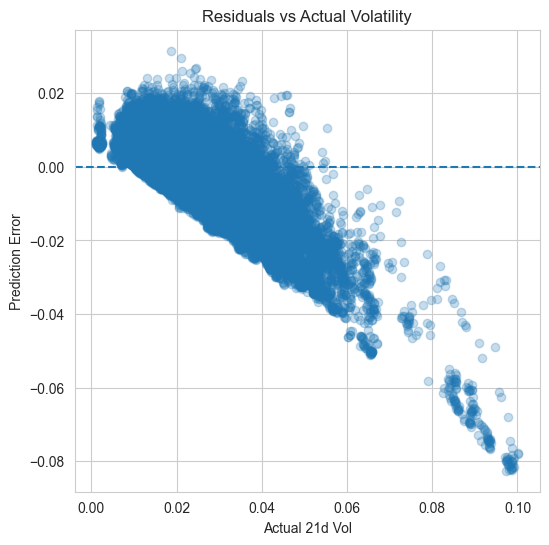

In [151]:
plt.figure(figsize=(6, 6))
error = unseen_results["y_pred"] - unseen_results["y_true"]
plt.scatter(unseen_results["y_true"], error, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 21d Vol")
plt.ylabel("Prediction Error")
plt.title("Residuals vs Actual Volatility")
plt.show()

## 7) Feature Importance (Permutation)

Estimate feature impact by shuffling one feature at a time and measuring validation degradation.


In [152]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_model(model, X_scaled, y_true, y_mean, y_std):
    pred_scaled = model.predict(X_scaled, verbose=0).reshape(-1)
    pred = pred_scaled * y_std + y_mean
    
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    corr = pd.Series(y_true).corr(pd.Series(pred))
    
    return {"rmse": rmse, "mae": mae, "corr": corr}

# baseline validation performance
base_metrics = evaluate_model(model, X_val_scaled, y_val, y_mean, y_std)
print("Base metrics:", base_metrics)

# permutation importance
rng = np.random.default_rng(42)
importance_rows = []

for j, feature in enumerate(feature_cols):
    X_perm = X_val_scaled.copy()

    # shuffle this feature across samples, preserving the 21-step sequence within each sample
    perm_idx = rng.permutation(X_perm.shape[0])
    X_perm[:, :, j] = X_perm[perm_idx, :, j]

    perm_metrics = evaluate_model(model, X_perm, y_val, y_mean, y_std)

    importance_rows.append({
        "feature": feature,
        "rmse_increase": perm_metrics["rmse"] - base_metrics["rmse"],
        "mae_increase": perm_metrics["mae"] - base_metrics["mae"],
        "corr_drop": base_metrics["corr"] - perm_metrics["corr"],
    })

importance_df = pd.DataFrame(importance_rows).sort_values(
    "rmse_increase", ascending=False
)

importance_df

Base metrics: {'rmse': np.float64(0.0072104052618797), 'mae': 0.004665113054215908, 'corr': np.float64(0.6050221758770165)}


,feature,rmse_increase,mae_increase,corr_drop
5,hl_range_mean_21,0.001136,0.000934,0.204440
4,hl_range_mean_5,0.000785,0.000604,0.136395
8,is_high_risk_cluster,0.000302,0.000239,0.047263
3,ret_std_21,0.000167,0.000051,0.022341
1,ret_std_5,0.000121,0.000158,0.005394
0,ret_abs_1,0.000108,0.000212,0.015290
7,vol_rel_21,0.000106,0.000194,0.010939
6,vol_rel_5,0.000098,0.000222,0.005605
2,ret_std_10,0.000028,0.000046,0.004210


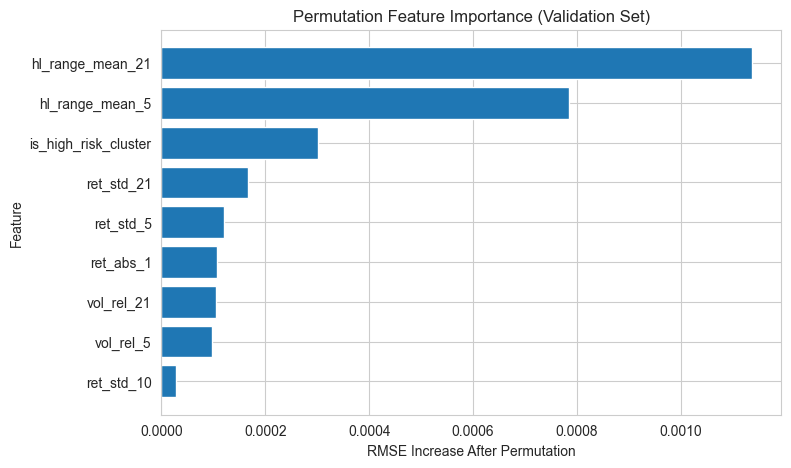

In [153]:
import matplotlib.pyplot as plt

plot_df = importance_df.sort_values("rmse_increase", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["rmse_increase"])
plt.xlabel("RMSE Increase After Permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (Validation Set)")
plt.show()

## 8) Stock-Level by Cluster Insights

Analyze stock-level volatility distribution and model quality by cluster to understand heterogeneity.


In [154]:
unseen_results = unseen_results.merge(
    cluster_map[["Symbol", "cluster", "Cluster_name"]],
    on="Symbol",
    how="left"
)

print(unseen_results[["Symbol", "cluster", "Cluster_name"]].drop_duplicates().head())
print(unseen_results["Cluster_name"].value_counts())

    Symbol  cluster Cluster_name
0        A        0    Lower-vol
209   AAPL        0    Lower-vol
418   ABBV        0    Lower-vol
627   ABNB        1   Higher-vol
836    ABT        0    Lower-vol
Cluster_name
Lower-vol     93631
Higher-vol    10659
Name: count, dtype: int64


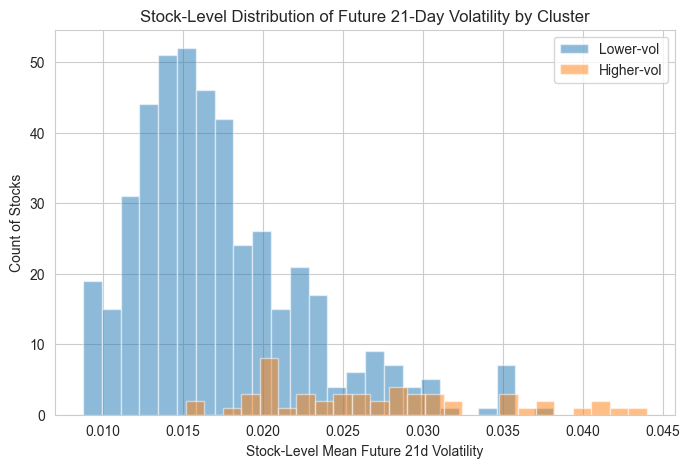

In [157]:
# 1) Aggregate to stock level (mean future vol per stock)
stock_plot_df = (
    unseen_results.dropna(subset=["Symbol", "Cluster_name", "y_true"])
                  .groupby(["Symbol", "Cluster_name"], as_index=False)["y_true"]
                  .mean()
                  .rename(columns={"y_true": "stock_mean_future_21d_vol"})
)

# 2) Histogram by cluster (stock-level)
cluster_names = stock_plot_df["Cluster_name"].unique()

plt.figure(figsize=(8, 5))
for name in cluster_names:
    tmp = stock_plot_df[stock_plot_df["Cluster_name"] == name]
    plt.hist(tmp["stock_mean_future_21d_vol"], bins=25, alpha=0.5, label=name)

plt.xlabel("Stock-Level Mean Future 21d Volatility")
plt.ylabel("Count of Stocks")
plt.title("Stock-Level Distribution of Future 21-Day Volatility by Cluster")
plt.legend()
plt.show()


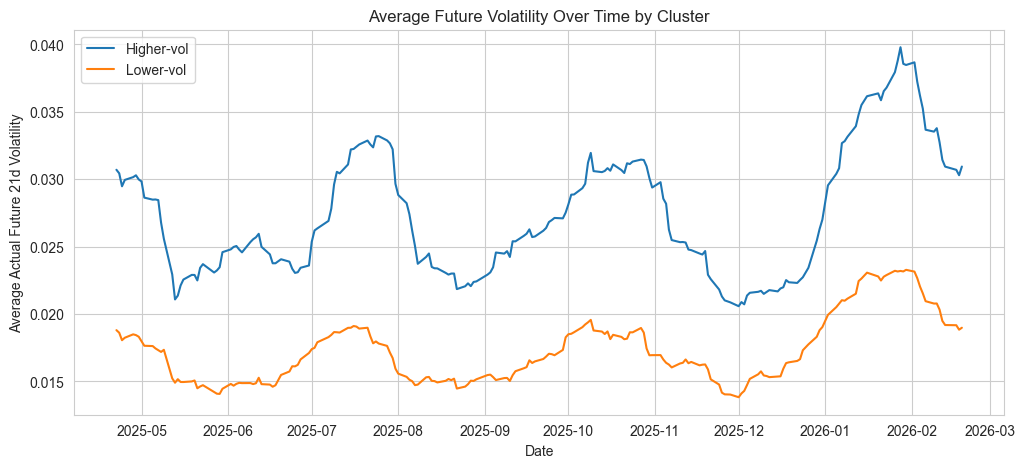

In [158]:
cluster_ts = (
    unseen_results
    .groupby(["Date", "Cluster_name"])["y_true"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
for name, g in cluster_ts.groupby("Cluster_name"):
    plt.plot(g["Date"], g["y_true"], label=name)

plt.xlabel("Date")
plt.ylabel("Average Actual Future 21d Volatility")
plt.title("Average Future Volatility Over Time by Cluster")
plt.legend()
plt.show()

In [160]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Add baseline predictions to unseen_results if not already present
if "baseline_pred" not in unseen_results.columns:
    baseline_map_unseen = (
        unseen_feat[["Symbol", "Date", "ret_std_21"]]
        .drop_duplicates(["Symbol", "Date"])
        .copy()
    )
    unseen_results = unseen_results.merge(
        baseline_map_unseen,
        on=["Symbol", "Date"],
        how="left"
    )
    unseen_results["baseline_pred"] = unseen_results["ret_std_21"]

rows = []
for (cluster, name), g in unseen_results.groupby(["cluster", "Cluster_name"]):
    g_clean = g.dropna(subset=["y_true", "y_pred", "baseline_pred"]).copy()
    if len(g_clean) == 0:
        continue
    rows.append({
        "cluster": cluster,
        "Cluster_name": name,
        "rmse_lstm": np.sqrt(mean_squared_error(g_clean["y_true"], g_clean["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g_clean["y_true"], g_clean["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g_clean["y_true"], g_clean["y_pred"]),
        "mae_baseline": mean_absolute_error(g_clean["y_true"], g_clean["baseline_pred"]),
        "r2_lstm": r2_score(g_clean["y_true"], g_clean["y_pred"]),
        "r2_baseline": r2_score(g_clean["y_true"], g_clean["baseline_pred"]),
        "corr_lstm": g_clean["y_true"].corr(g_clean["y_pred"]),
        "corr_baseline": g_clean["y_true"].corr(g_clean["baseline_pred"]),
        "n_obs": len(g_clean)
    })

by_cluster_perf = pd.DataFrame(rows)
by_cluster_perf

,cluster,Cluster_name,rmse_lstm,rmse_baseline,mae_lstm,mae_baseline,r2_lstm,r2_baseline,corr_lstm,corr_baseline,n_obs
0,0,Lower-vol,0.006998,0.009703,0.004795,0.006438,0.264767,-0.413351,0.515142,0.366429,93631
1,1,Higher-vol,0.011054,0.015382,0.008226,0.010928,0.220708,-0.509165,0.491926,0.300645,10659


Stocks evaluated: 499
Avg unseen R² (LSTM): -0.7921709894895076
Avg unseen R² (Baseline): -2.077229897682638
Pct symbols where LSTM R² > baseline R²: 0.9218436873747495

Top symbols where LSTM beats baseline on R²:
    Symbol   r2_lstm  r2_baseline  r2_gain_lstm_minus_baseline
181   FANG -2.353455   -16.539520                    14.186065
35     APA -3.201806   -14.276884                    11.075078
150    DVN -0.608948   -10.866097                    10.257149
365     PH -1.599798    -7.811929                     6.212131
202   GEHC -0.739103    -6.663605                     5.924503
8      ADI -0.136900    -5.802558                     5.665657
106    COP -0.735783    -6.182999                     5.447216
362    PFG -1.205052    -6.404204                     5.199151
51      BA -0.858779    -5.989373                     5.130594
405    SLB -0.886924    -5.779975                     4.893051

Symbols where LSTM is most off vs baseline on R²:
    Symbol    r2_lstm  r2_baseline  r2_ga

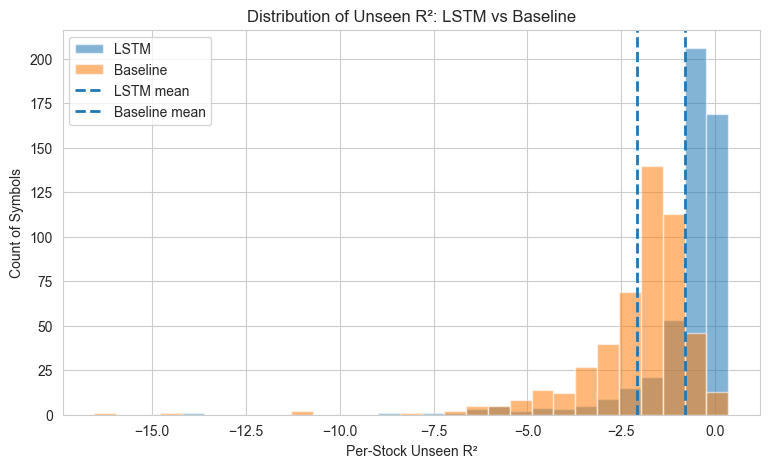

In [161]:
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Per-stock unseen R²: LSTM vs baseline
r2_rows = []
for symbol, g in unseen_results.groupby("Symbol"):
    g = g.dropna(subset=["y_true", "y_pred", "baseline_pred"]).copy()
    if len(g) < 5 or g["y_true"].nunique() < 2:
        continue

    r2_lstm = r2_score(g["y_true"], g["y_pred"])
    r2_baseline = r2_score(g["y_true"], g["baseline_pred"])

    row = {
        "Symbol": symbol,
        "r2_lstm": r2_lstm,
        "r2_baseline": r2_baseline,
        "r2_gain_lstm_minus_baseline": r2_lstm - r2_baseline,
        "n_obs": len(g),
    }

    if "cluster" in g.columns:
        row["cluster"] = g["cluster"].iloc[0]
    if "Cluster_name" in g.columns:
        row["Cluster_name"] = g["Cluster_name"].iloc[0]

    r2_rows.append(row)

r2_by_stock = pd.DataFrame(r2_rows).sort_values("r2_gain_lstm_minus_baseline", ascending=False)

print("Stocks evaluated:", len(r2_by_stock))
print("Avg unseen R² (LSTM):", r2_by_stock["r2_lstm"].mean())
print("Avg unseen R² (Baseline):", r2_by_stock["r2_baseline"].mean())
print("Pct symbols where LSTM R² > baseline R²:", (r2_by_stock["r2_gain_lstm_minus_baseline"] > 0).mean())

print("\nTop symbols where LSTM beats baseline on R²:")
print(r2_by_stock[["Symbol", "r2_lstm", "r2_baseline", "r2_gain_lstm_minus_baseline"]].head(10))

print("\nSymbols where LSTM is most off vs baseline on R²:")
print(r2_by_stock[["Symbol", "r2_lstm", "r2_baseline", "r2_gain_lstm_minus_baseline"]].tail(10))

all_vals = pd.concat([r2_by_stock["r2_lstm"], r2_by_stock["r2_baseline"]])
bins = np.linspace(all_vals.min(), all_vals.max(), 30)

plt.figure(figsize=(9, 5))
plt.hist(r2_by_stock["r2_lstm"], bins=bins, alpha=0.55, label="LSTM")
plt.hist(r2_by_stock["r2_baseline"], bins=bins, alpha=0.55, label="Baseline")
plt.axvline(r2_by_stock["r2_lstm"].mean(), linestyle="--", linewidth=2, label="LSTM mean")
plt.axvline(r2_by_stock["r2_baseline"].mean(), linestyle="--", linewidth=2, label="Baseline mean")
plt.xlabel("Per-Stock Unseen R²")
plt.ylabel("Count of Symbols")
plt.title("Distribution of Unseen R²: LSTM vs Baseline")
plt.legend()
plt.show()

# plt.figure(figsize=(8, 4))
# plt.boxplot([r2_by_stock["r2_lstm"], r2_by_stock["r2_baseline"]], tick_labels=["LSTM", "Baseline"])
# plt.ylabel("Per-Stock Unseen R²")
# plt.title("Unseen R² Spread by Model")
# plt.show()



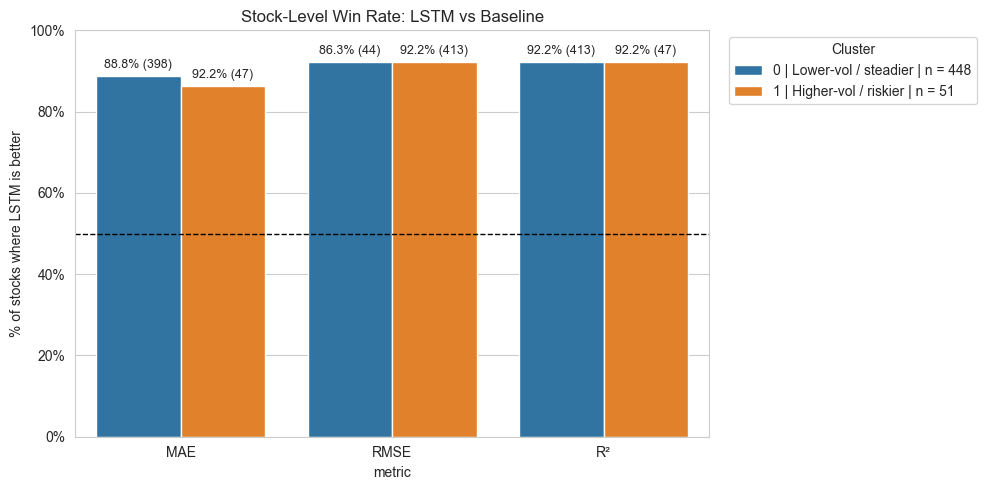

In [162]:
# annotate as "88.8% (398)" and legend as "... | n = X"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_style("whitegrid")

sp = stock_level.copy()
sp["cluster_label"] = sp["cluster"].astype(str) + " | " + sp["Cluster_name"].fillna("Unknown")

sp["win_mae"] = sp["mae_gap_lstm_minus_baseline"] < 0
sp["win_rmse"] = sp["rmse_gap_lstm_minus_baseline"] < 0
sp["win_r2"] = sp["r2_gain_lstm_minus_baseline"] > 0

win_long = sp.melt(
    id_vars=["Symbol", "cluster_label"],
    value_vars=["win_mae", "win_rmse", "win_r2"],
    var_name="metric",
    value_name="lstm_better"
)
win_long["metric"] = win_long["metric"].map({
    "win_mae": "MAE",
    "win_rmse": "RMSE",
    "win_r2": "R²"
})

agg = (
    win_long.groupby(["cluster_label", "metric"], as_index=False)
    .agg(
        n_stocks=("Symbol", "nunique"),
        n_wins=("lstm_better", "sum")
    )
)
agg["pct"] = agg["n_wins"] / agg["n_stocks"]

metric_order = ["MAE", "RMSE", "R²"]
hue_order = sorted(agg["cluster_label"].unique())

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=agg,
    x="metric",
    y="pct",
    hue="cluster_label",
    order=metric_order,
    hue_order=hue_order
)

ax.axhline(0.5, ls="--", c="black", lw=1)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylabel("% of stocks where LSTM is better")
ax.set_title("Stock-Level Win Rate: LSTM vs Baseline")

# annotations: "88.8% (398)"
ann_rows = []
for m in metric_order:
    for h in hue_order:
        ann_rows.append(agg[(agg["metric"] == m) & (agg["cluster_label"] == h)].iloc[0])

for bar, row in zip(ax.patches, ann_rows):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.012,
        f"{row['pct']*100:.1f}% ({int(row['n_wins'])})",
        ha="center",
        va="bottom",
        fontsize=9
    )

# legend: "0 | Lower-vol / steadier | n = 448"
n_by_cluster = sp.groupby("cluster_label")["Symbol"].nunique().to_dict()
handles, labels = ax.get_legend_handles_labels()
legend_labels = [f"{lbl} | n = {n_by_cluster.get(lbl, 0)}" for lbl in labels]
ax.legend(handles, legend_labels, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


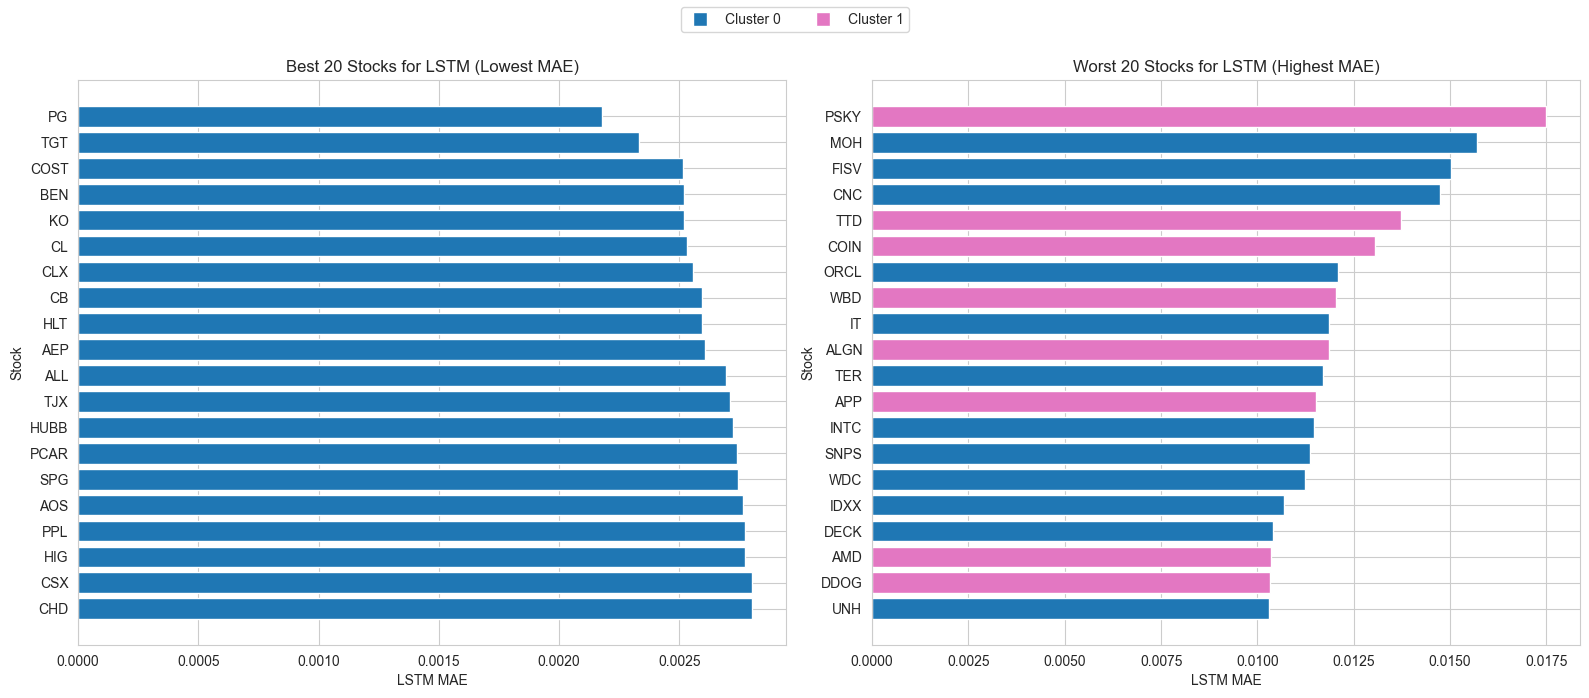

In [163]:
# Best/Worst LSTM stocks with bar color = cluster
# Blue = cluster 0, Pink = cluster 1

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

top_n = 20
min_obs = 50

# Assuming stock_perf already exists from previous cell
# If not, run that cell first.
plot_df = stock_perf.copy()
plot_df = plot_df[plot_df["n_obs"] >= min_obs].copy()

best = plot_df.nsmallest(top_n, "mae_lstm").sort_values("mae_lstm", ascending=False)
worst = plot_df.nlargest(top_n, "mae_lstm").sort_values("mae_lstm", ascending=True)

cluster_colors = {0: "#1f77b4", 1: "#e377c2"}  # blue / pink
default_color = "#7f7f7f"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Best
best_colors = [cluster_colors.get(int(c), default_color) for c in best["cluster"]]
axes[0].barh(best["Symbol"], best["mae_lstm"], color=best_colors)
axes[0].set_title(f"Best {top_n} Stocks for LSTM (Lowest MAE)")
axes[0].set_xlabel("LSTM MAE")
axes[0].set_ylabel("Stock")

# Worst
worst_colors = [cluster_colors.get(int(c), default_color) for c in worst["cluster"]]
axes[1].barh(worst["Symbol"], worst["mae_lstm"], color=worst_colors)
axes[1].set_title(f"Worst {top_n} Stocks for LSTM (Highest MAE)")
axes[1].set_xlabel("LSTM MAE")
axes[1].set_ylabel("Stock")

# Shared legend
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cluster_colors[0], markersize=10, label='Cluster 0'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cluster_colors[1], markersize=10, label='Cluster 1'),
]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
